In [2]:
%pip install keras tensorflow

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 13.9 MB/s eta 0:00:0031m12.1 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.2/572.2 MB 9.6 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.0/412.0 KB 140.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 KB 9.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 51.2 MB/s eta 0:00:0031m61.5 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.7/310.7 KB 24.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.5/452.5 KB 36.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 KB 25.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 KB 10.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 46.5 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from matplotlib import pyplot as plt

I0000 00:00:1790670660.591312    6087 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790670660.600697    6087 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790670660.634820    6087 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790670661.501486    6087 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [4]:
from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from matplotlib import pyplot as plt


In [5]:
(x_train,y_train),(x_valid,y_valid) = mnist.load_data()
x_train.shape

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


(60000, 28, 28)

In [6]:
y_train.shape

(60000,)

In [7]:
y_train[0:12]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5], dtype=uint8)

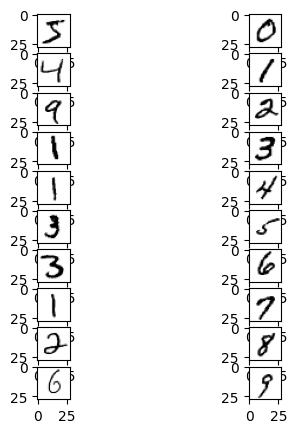

In [9]:
plt.figure(figsize=(5,5)) 
for k in range(20):
    plt.subplot(10,2,k+1) 
    plt.imshow(x_train[k],cmap='Greys') 
    plt.axis('on') 
plt.show()

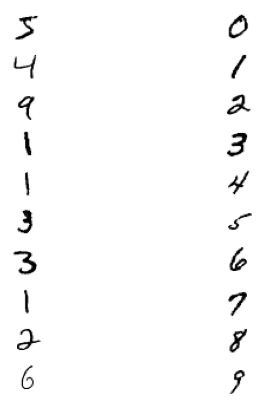

In [10]:
plt.figure(figsize=(5,5))
for k in range(20):  
    plt.subplot(10,2,k+1)  
    plt.imshow(x_train[k],cmap='Greys')  
    plt.axis('off') 
plt.show()

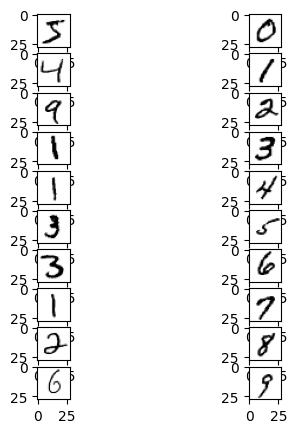

In [11]:
plt.figure(figsize=(5,5))
for k in range(20): 
    plt.subplot(10,2,k+1) 
    plt.imshow(x_train[k],cmap='Greys') 
    plt.axis('on') 
plt.show()

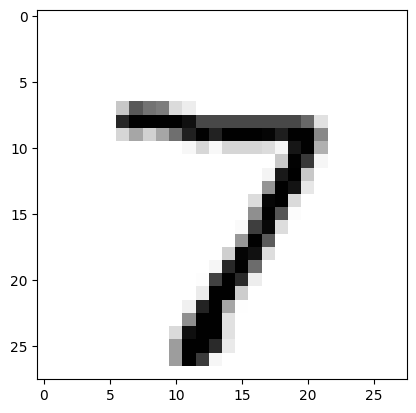

In [12]:
plt.imshow(x_valid[0],cmap='Greys')

In [13]:
y_valid.shape

(10000,)

In [14]:
x_valid[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [15]:
y_valid[0]

np.uint8(7)

In [17]:
x_train = x_train.reshape(60000,784).astype('float32')
x_valid = x_valid.reshape(10000,784).astype('float32')
x_train/=255 
x_valid/=255

In [20]:
from tensorflow.keras.utils import to_categorical

n_classes = 10

y_train = to_categorical(y_train, n_classes)
y_valid = to_categorical(y_valid, n_classes)

y_valid[0]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

In [21]:
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [22]:
x_valid[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [23]:
x_valid[3]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [24]:
y_valid[3]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [25]:
model = Sequential()
model.add(Dense(64, activation='sigmoid', input_shape=(784,))) 
model.add(Dense(10, activation='softmax')) 
model.summary()

/home/oem/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1790671393.304436    6087 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
(64*784)

50176

In [27]:
(64*784)+64

50240

In [28]:
(10*64)

640

In [29]:
(10*64)+10

650

In [30]:
((10*64)+10) +((64*784)+64)

50890

In [33]:
model.compile(loss='mean_squared_error',optimizer=SGD(learning_rate=0.03),metrics=['accuracy'])
history= model.fit(x_train,y_train,batch_size=128,epochs=75,verbose=1)

Epoch 1/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 911us/step - accuracy: 0.1377 - loss: 0.0909
Epoch 2/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 926us/step - accuracy: 0.2038 - loss: 0.0896
Epoch 3/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 854us/step - accuracy: 0.2260 - loss: 0.0886
Epoch 4/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 875us/step - accuracy: 0.2383 - loss: 0.0877
Epoch 5/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 882us/step - accuracy: 0.2537 - loss: 0.0867
Epoch 6/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step - accuracy: 0.2700 - loss: 0.0857
Epoch 7/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 958us/step - accuracy: 0.2870 - loss: 0.0846
Epoch 8/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step - accuracy: 0.3078 - loss: 0.0835
Epoch 9/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 930us/step - accuracy: 0.3331 - loss: 0.0822
Epoch 10/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 907us/step - accuracy: 0.3641 - loss: 0.0809
Epoch 11/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 920us/step - accuracy: 0.3997 - loss: 0.0796
Epoch 12/75
469/469 ━━━━━━━━━━

NameError: name 'Text' is not defined

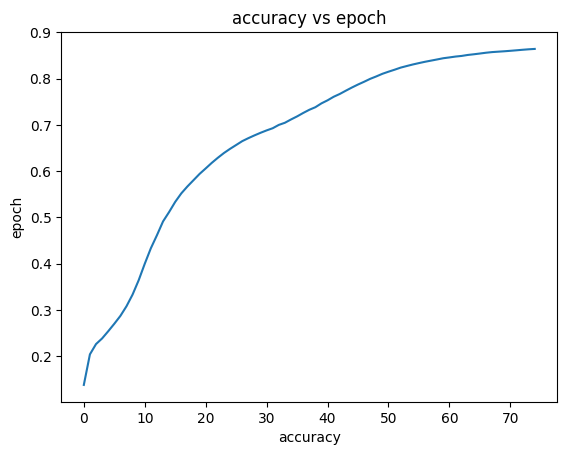

In [34]:
plt.plot(history.history['accuracy'])
plt.title('accuracy vs epoch') 
plt.xlabel('accuracy') 
plt.ylabel('epoch') 
Text(0, 0.5, 'epoch')

NameError: name 'Text' is not defined

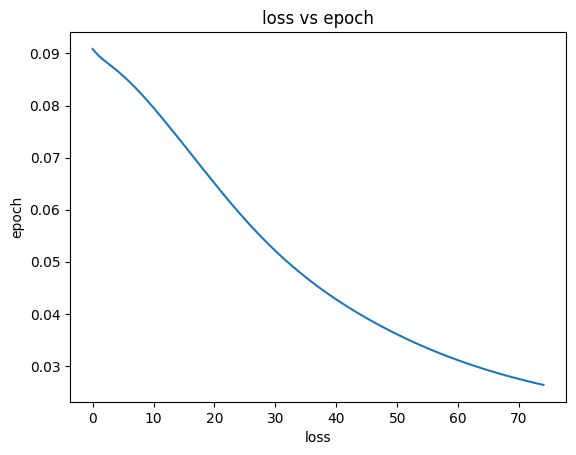

In [35]:
plt.plot(history.history['loss']) 
plt.title('loss vs epoch') 
plt.xlabel('loss') 
plt.ylabel('epoch') 
Text(0, 0.5, 'epoch')